In [1]:
%load_ext autoreload
%autoreload 2

In [21]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import glob
from time import time
import os
from dataclasses import replace
from RaTag.core.datatypes import Run, SetPmt, S2Areas
from RaTag.core.config import TimingConfig, IntegrationConfig, FitConfig, AlphaCalibrationConfig
from RaTag.core.wfm2read_fast import wfm2read
from RaTag.io.bootstrap import bootstrap_from_config
from RaTag.alphas.alphas_workflow import map_alpha_events
from RaTag.alphas.alphas_calibration import map_alpha_plots, map_alpha_calibrations


from RaTag.thgem_tpc.drift_workflow import map_drift_physics
from RaTag.thgem_tpc.timing_workflow import map_time_windows, resolve_set_timing, map_timing_plots
from RaTag.thgem_tpc.recoil_workflow import map_recoil_integration, map_recoil_fits, map_recoil_plots

from RaTag.thgem_tpc.multiiso_workflow import map_multiiso_separation, map_multiiso_s2_vs_field, map_multiiso_hist_grid
from RaTag.io import file_ops
from RaTag.plotting import plot_s2areas_summary

%matplotlib inline

# Initialize test run and drift properties

In [22]:
config_path = '/Users/pabloherrero/sabat/RaTagging/configs/recoils/run43_analysis.yaml'

run = bootstrap_from_config(config_path)
config = file_ops.load_yaml(config_path)
alpha_config = config.get('energy_mapping', AlphaCalibrationConfig())
alpha_config = AlphaCalibrationConfig(**{k: v for k, v in alpha_config.items() if hasattr(AlphaCalibrationConfig, k)})

Found 9 directories in RUN43_EL25kVcm
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0120_Anode1120 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0188_Anode1188 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0288_Anode1288 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0480_Anode1480 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0576_Anode1576 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0672_Anode1672 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0768_Anode1768 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0864_Anode1864 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0960_Anode1960 with 200 waveforms.
  → Bootstrapped 9 PMT Sets and 9 Alpha Sets. (Multi-Isotope: True)


In [4]:
run = map_drift_physics(run, force=False)

  📂 Cache Hit: Loaded metadata for 'drift_field in FieldScan_Gate0120_Anode1120'
  📂 Cache Hit: Loaded metadata for 'red_EL_field in FieldScan_Gate0120_Anode1120'
  📂 Cache Hit: Loaded metadata for 'time_drift in FieldScan_Gate0120_Anode1120'
  📂 Cache Hit: Loaded metadata for 'drift_field in FieldScan_Gate0188_Anode1188'
  📂 Cache Hit: Loaded metadata for 'red_EL_field in FieldScan_Gate0188_Anode1188'
  📂 Cache Hit: Loaded metadata for 'time_drift in FieldScan_Gate0188_Anode1188'
  📂 Cache Hit: Loaded metadata for 'drift_field in FieldScan_Gate0288_Anode1288'
  📂 Cache Hit: Loaded metadata for 'red_EL_field in FieldScan_Gate0288_Anode1288'
  📂 Cache Hit: Loaded metadata for 'time_drift in FieldScan_Gate0288_Anode1288'
  📂 Cache Hit: Loaded metadata for 'drift_field in FieldScan_Gate0480_Anode1480'
  📂 Cache Hit: Loaded metadata for 'red_EL_field in FieldScan_Gate0480_Anode1480'
  📂 Cache Hit: Loaded metadata for 'time_drift in FieldScan_Gate0480_Anode1480'
  📂 Cache Hit: Loaded metada

In [23]:
alpha_config

AlphaCalibrationConfig(force=False, max_frames=None, savgol_window=501, pattern='*.wfm', nbins=200, n_sigma={'Th228': [4.0, 2.0], 'Ra224': [2.0, 4.0], 'default': [3.0, 3.0]}, use_quadratic=True, energy_range=[4, 10.2])

In [27]:
run = map_alpha_events(run, force=False)
run = map_alpha_calibrations(run, config=alpha_config, force=False)
run = map_alpha_plots(run, force=False)


RECONSTRUCTING ALPHA ENERGIES: RUN_43
Force flag: False
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0120_Anode1120'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0188_Anode1188'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0288_Anode1288'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0480_Anode1480'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0576_Anode1576'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0672_Anode1672'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0768_Anode1768'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0864_Anode1864'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0960_Anode1960'

CALIBRATING ALPHA ENERGIES: RUN_43
  📂 Cache Hit: Loaded metadata for 'calib_a in FieldScan_Gate0120_Anode1120'
  📂 Cache Hit: Loaded metadata for 'calib_a in FieldScan

In [28]:
run = map_recoil_integration(run, force=False)
run = map_recoil_plots(run, force=True);


INTEGRATING S2 RECOILS: RUN_43
  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0120_Anode1120'
  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0188_Anode1188'
  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0288_Anode1288'
  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0480_Anode1480'
  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0576_Anode1576'
  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0672_Anode1672'
  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0768_Anode1768'
  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0864_Anode1864'
  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0960_Anode1960'

GENERATING RECOIL S2 AREAS QA PLOTS: RUN_43
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/s2_areas/FieldScan_Gate0120_Anode1120_s2_areas.npz
  Loaded fit model for FieldSc

/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:20: RuntimeWarning: divide by zero encountered in divide
  tail = A_tail / (denom_safe)**m


  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/s2_areas/FieldScan_Gate0480_Anode1480_s2_areas.npz
  Loaded fit model for FieldScan_Gate0480_Anode1480 with lower_bound=0.0
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/s2_areas/FieldScan_Gate0576_Anode1576_s2_areas.npz
  Loaded fit model for FieldScan_Gate0576_Anode1576 with lower_bound=0.0
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/s2_areas/FieldScan_Gate0672_Anode1672_s2_areas.npz
  Loaded fit model for FieldScan_Gate0672_Anode1672 with lower_bound=0.0
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/s2_areas/FieldScan_Gate0768_Anode1768_s2_areas.npz
  Loaded fit model for FieldScan_Gate0768_Anode1768 with lower_bound=0.0
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/s2_areas/FieldScan_Gate0864_Anode1864_s2_areas.npz


/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:20: RuntimeWarning: overflow encountered in divide
  tail = A_tail / (denom_safe)**m


  Loaded fit model for FieldScan_Gate0864_Anode1864 with lower_bound=0.0
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/s2_areas/FieldScan_Gate0960_Anode1960_s2_areas.npz
  Loaded fit model for FieldScan_Gate0960_Anode1960 with lower_bound=0.0
  → Saved: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/plots/s2_areas/multi/RUN_43_histograms.png
  → Saved: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/plots/s2_areas/multi/RUN_43_s2_vs_field.png


In [29]:
runm = map_multiiso_separation(run, force=True)


SEPARATING MULTI-ISOTOPE SETS: RUN_43

  Mapping FieldScan_Gate0120_Anode1120...
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/s2_areas/FieldScan_Gate0120_Anode1120_s2_areas.npz
  Loading alpha_energies arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/alpha_energies/FieldScan_Gate0120_Anode1120_alpha_energies.npz
    ✓ Separated Th228: 13866 events
    ✓ Separated Ra224: 8164 events
    ✓ Separated Po216: 3933 events
    ✓ Separated Po212: 5620 events

  Mapping FieldScan_Gate0188_Anode1188...
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/s2_areas/FieldScan_Gate0188_Anode1188_s2_areas.npz
  Loading alpha_energies arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/alpha_energies/FieldScan_Gate0188_Anode1188_alpha_energies.npz
    ✓ Separated Th228: 16174 events
    ✓ Separated Ra224: 9895 events
    ✓ Separated Po216: 4626 events
    ✓ Separated Po212: 5937 events

  Mappin

In [30]:
for iso, iso_run in runm.items():
    fitted_run = map_recoil_fits(iso_run, force=True)
    runm[iso] = fitted_run  # Update the dict with the fitted run
    plotted_run = map_recoil_plots(fitted_run, force=True)


FITTING S2 AREA DISTRIBUTIONS: RUN_43_Th228
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Th228/FieldScan_Gate0120_Anode1120_Th228_s2_areas.npz
Histogramming with bin_cuts: (0, 50)
  Fit success: True, χ²/DOF: 440.38
  ✓ Fit: μ=13.830 ± 0.283 mV·µs
  ✓ FieldScan_Gate0120_Anode1120_Th228: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Th228/FieldScan_Gate0188_Anode1188_Th228_s2_areas.npz
Histogramming with bin_cuts: (0, 50)
  Fit success: True, χ²/DOF: 224.76
  ✓ Fit: μ=13.637 ± 0.325 mV·µs
  ✓ FieldScan_Gate0188_Anode1188_Th228: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Th228/FieldScan_Gate0288_Anode1288_Th228_s2_areas.npz
Histogramming with bin_cuts: (0, 50)
  Fit success: True, χ²/DOF: 389.25
  ✓ Fit: μ=15.247 ± 0.347 mV

/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:20: RuntimeWarning: overflow encountered in divide
  tail = A_tail / (denom_safe)**m


  ✓ FieldScan_Gate0672_Anode1672_Th228: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Th228/FieldScan_Gate0768_Anode1768_Th228_s2_areas.npz
Histogramming with bin_cuts: (0, 50)
  Fit success: True, χ²/DOF: 551.57
  ✓ Fit: μ=20.359 ± 0.357 mV·µs
  ✓ FieldScan_Gate0768_Anode1768_Th228: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Th228/FieldScan_Gate0864_Anode1864_Th228_s2_areas.npz
Histogramming with bin_cuts: (0, 50)
  Fit success: True, χ²/DOF: 1022.78
  ✓ Fit: μ=22.033 ± 0.283 mV·µs
  ✓ FieldScan_Gate0864_Anode1864_Th228: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Th228/FieldScan_Gate0960_Anode1960_Th228_s2_areas.npz
Histogramming with bin_cuts: (0, 50)
  Fit success: Tr

/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:20: RuntimeWarning: divide by zero encountered in divide
  tail = A_tail / (denom_safe)**m


  ✓ FieldScan_Gate0960_Anode1960_Th228: Computed 'area_s2_fit_success' and stored metadata

GENERATING RECOIL S2 AREAS QA PLOTS: RUN_43_Th228
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Th228/FieldScan_Gate0120_Anode1120_Th228_s2_areas.npz
  Loaded fit model for FieldScan_Gate0120_Anode1120 with lower_bound=0.0
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Th228/FieldScan_Gate0188_Anode1188_Th228_s2_areas.npz
  Loaded fit model for FieldScan_Gate0188_Anode1188 with lower_bound=0.0
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Th228/FieldScan_Gate0288_Anode1288_Th228_s2_areas.npz
  Loaded fit model for FieldScan_Gate0288_Anode1288 with lower_bound=0.0
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Th228/FieldScan_Gate0480_Anode1480_Th228_s2_areas.npz
  Loaded fit model for 

...

  ✓ FieldScan_Gate0288_Anode1288_Po212: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Po212/FieldScan_Gate0480_Anode1480_Po212_s2_areas.npz
Histogramming with bin_cuts: (0, 50)
  Fit success: True, χ²/DOF: 409.95
  ✓ Fit: μ=18.424 ± 0.283 mV·µs
  ✓ FieldScan_Gate0480_Anode1480_Po212: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Po212/FieldScan_Gate0576_Anode1576_Po212_s2_areas.npz
Histogramming with bin_cuts: (0, 50)
  Fit success: True, χ²/DOF: 478.15
  ✓ Fit: μ=18.200 ± 0.283 mV·µs
  ✓ FieldScan_Gate0576_Anode1576_Po212: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Po212/FieldScan_Gate0672_Anode1672_Po212_s2_areas.npz
Histogramming with bin_cuts: (0, 50)
  Fit success: Tru

/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:20: RuntimeWarning: divide by zero encountered in divide
  tail = A_tail / (denom_safe)**m
/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:20: RuntimeWarning: divide by zero encountered in divide
  tail = A_tail / (denom_safe)**m


  ✓ FieldScan_Gate0672_Anode1672_Po212: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Po212/FieldScan_Gate0768_Anode1768_Po212_s2_areas.npz
Histogramming with bin_cuts: (0, 50)
  Fit success: True, χ²/DOF: 673.50
  ✓ Fit: μ=19.011 ± 0.283 mV·µs
  ✓ FieldScan_Gate0768_Anode1768_Po212: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Po212/FieldScan_Gate0864_Anode1864_Po212_s2_areas.npz
Histogramming with bin_cuts: (0, 50)
  Fit success: True, χ²/DOF: 660.42
  ✓ Fit: μ=18.340 ± 0.283 mV·µs
  ✓ FieldScan_Gate0864_Anode1864_Po212: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Po212/FieldScan_Gate0960_Anode1960_Po212_s2_areas.npz
Histogramming with bin_cuts: (0, 50)
  Fit success: Tru

/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:20: RuntimeWarning: divide by zero encountered in divide
  tail = A_tail / (denom_safe)**m
/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:20: RuntimeWarning: divide by zero encountered in divide
  tail = A_tail / (denom_safe)**m


  ✓ FieldScan_Gate0960_Anode1960_Po212: Computed 'area_s2_fit_success' and stored metadata

GENERATING RECOIL S2 AREAS QA PLOTS: RUN_43_Po212
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Po212/FieldScan_Gate0120_Anode1120_Po212_s2_areas.npz
  Loaded fit model for FieldScan_Gate0120_Anode1120 with lower_bound=0.0
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Po212/FieldScan_Gate0188_Anode1188_Po212_s2_areas.npz
  Loaded fit model for FieldScan_Gate0188_Anode1188 with lower_bound=0.0
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Po212/FieldScan_Gate0288_Anode1288_Po212_s2_areas.npz
  Loaded fit model for FieldScan_Gate0288_Anode1288 with lower_bound=0.0
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Po212/FieldScan_Gate0480_Anode1480_Po212_s2_areas.npz
  Loaded fit model for 

In [31]:
run = map_multiiso_s2_vs_field(run, spawned_runs=runm, force=True)
run = map_multiiso_hist_grid(run, spawned_runs=runm, force=True)


PLOTTING MULTI-ISOTOPE S2 VS FIELD: RUN_43
  → Saved: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/plots/s2_areas/multi/RUN_43_s2_vs_field_multiiso.png

PLOTTING MULTI-ISOTOPE HISTOGRAMS: RUN_43
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Th228/FieldScan_Gate0120_Anode1120_Th228_s2_areas.npz
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Ra224/FieldScan_Gate0120_Anode1120_Ra224_s2_areas.npz
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Po216/FieldScan_Gate0120_Anode1120_Po216_s2_areas.npz
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Po212/FieldScan_Gate0120_Anode1120_Po212_s2_areas.npz
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Th228/FieldScan_Gate0188_Anode1188_Th228_s2_areas.npz
  Loading s2_areas arrays

/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:20: RuntimeWarning: overflow encountered in divide
  tail = A_tail / (denom_safe)**m



  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Po212/FieldScan_Gate0576_Anode1576_Po212_s2_areas.npz
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Th228/FieldScan_Gate0672_Anode1672_Th228_s2_areas.npz
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Ra224/FieldScan_Gate0672_Anode1672_Ra224_s2_areas.npz
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Po216/FieldScan_Gate0672_Anode1672_Po216_s2_areas.npz
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Po212/FieldScan_Gate0672_Anode1672_Po212_s2_areas.npz
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Th228/FieldScan_Gate0768_Anode1768_Th228_s2_areas.npz
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN4

In [27]:
fitpo0.params['sig_x0'].value

16.73337616035107

In [25]:
set6 = run.sets[6]
s2_areas = load_s2areas(set6)

  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN35_EL20kVcm/s2_areas/FieldScan_Gate0480_Anode1280_s2_areas.npz


In [27]:
s2_areas

S2Areas(uids=array([  65,   68,   69, ..., 2253, 2259, 2262]), areas=array([1.29925449, 0.98648967, 2.22679696, ..., 1.4565153 , 0.92353287,
       2.8724546 ]))

# Debug S2 area fitting

In [101]:
from RaTag.el_tpc.fit_s2_area import fit_finetune_s2area
from RaTag.core.config import FinetuneConfig
from RaTag.plotting import plot_finetune_s2area

In [126]:
setRa0 = runm['Ra224'].sets[0]
s2_areas = file_ops.load_s2areas(setRa0)

config = FinetuneConfig(
    bin_cuts=(0, 50),
    nbins=200,

    bg_amplitude = 200,
    bg_center = 3,
    bg_sigma = 0.1,

    sig_N = 400,
    sig_x0 = 27,
    sig_sigma = 10,
    sig_m = 1.5,
    sig_beta = 1.5
)

  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Ra224/FieldScan_Gate0120_Anode1120_Ra224_s2_areas.npz


In [102]:
# plt.hist(s2_areas.areas, bins=100, range=(0, 50));

In [127]:
results_finetune = fit_finetune_s2area(s2_areas.areas, config)
results_finetune

{'peak_position': 14.030649012955873,
 'sigma': 7.101587059092315,
 'ci95': np.float64(0.15682073990583417),
 'result_bg': <lmfit.model.ModelResult at 0x1435dedf0>,
 'result_sig': <lmfit.model.ModelResult at 0x1435d7be0>}

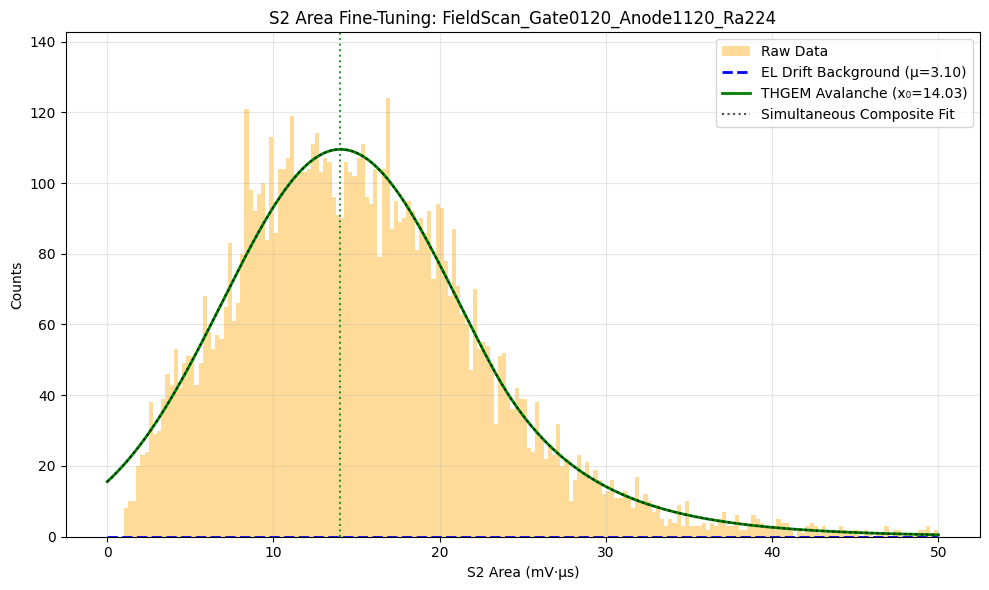

In [128]:
fig = plot_finetune_s2area(s2_areas.areas, config, fit_results=results_finetune, set_name=setRa0.name,)